## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.model_selection import train_test_split
import seaborn as sns

### Importing the Dataset

In [2]:
# Load Dataset
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

### Understanding the Data

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Missing Values

<Axes: >

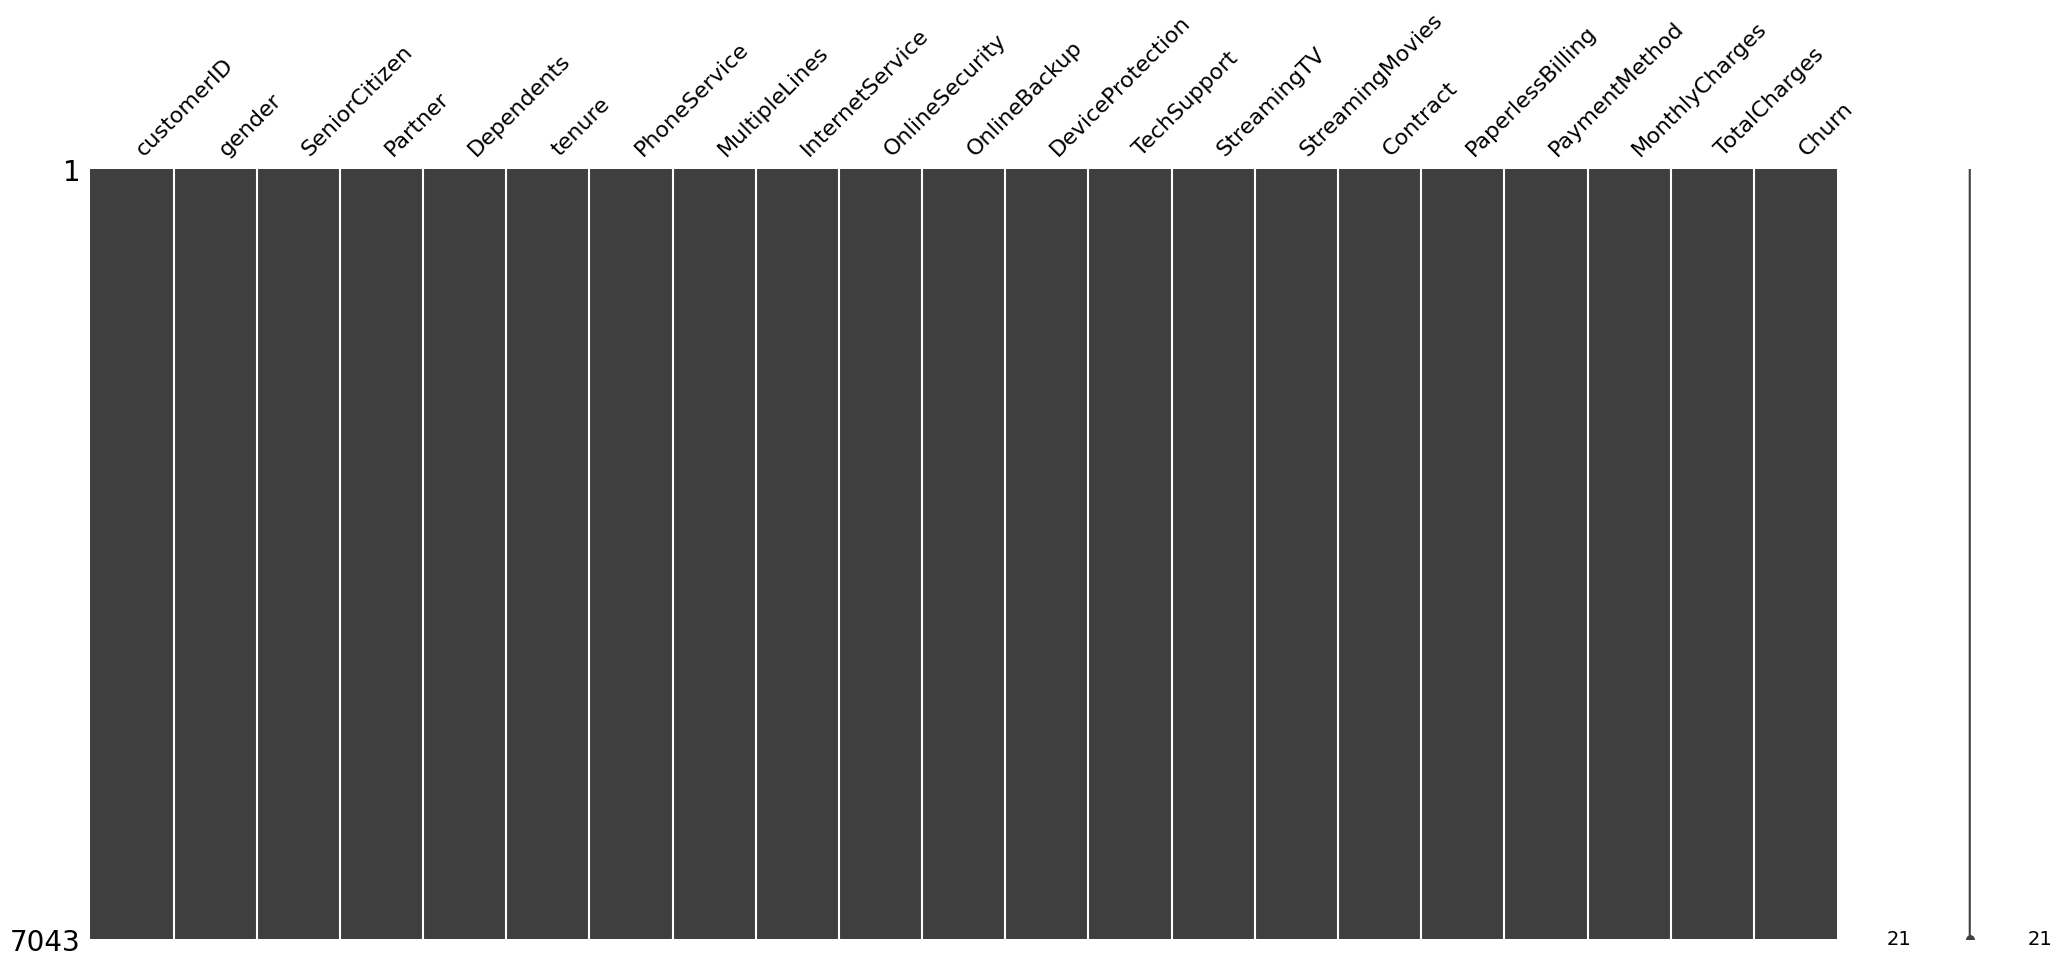

In [7]:
msno.matrix(df)

In [8]:
# Check for empty strings and replace them with NaN
df = df.replace(r"^\s*$", pd.NA, regex=True)
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,<NA>,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,<NA>,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,<NA>,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,<NA>,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,<NA>,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,<NA>,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,<NA>,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,<NA>,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,<NA>,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,<NA>,No


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

/tmp/ipython-input-3727035366.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


4. Feature Engineering

In [11]:
# Tenure Groups
df['TenureGroup'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,60,100],
                           labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr'])

# Avg Monthly Spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Count number of services
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
            'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

df['ServiceCount'] = df[services].apply(lambda x: sum(x=='Yes'), axis=1)

# Simulated customer support interactions
np.random.seed(42)
df['SupportTickets'] = np.random.poisson(1.2, len(df))
df['HighComplaintFlag'] = (df['SupportTickets'] > 3).astype(int)

In [12]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Data Manipulation

In [13]:
df = df.drop(columns=['customerID'], axis=1, errors='ignore')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,ServiceCount,SupportTickets,HighComplaintFlag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0,0-1yr,14.925000,1,2,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,2-4yr,53.985714,3,1,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,0-1yr,36.050000,3,0,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,40.016304,3,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,0-1yr,50.550000,1,3,0


## Visualize Data

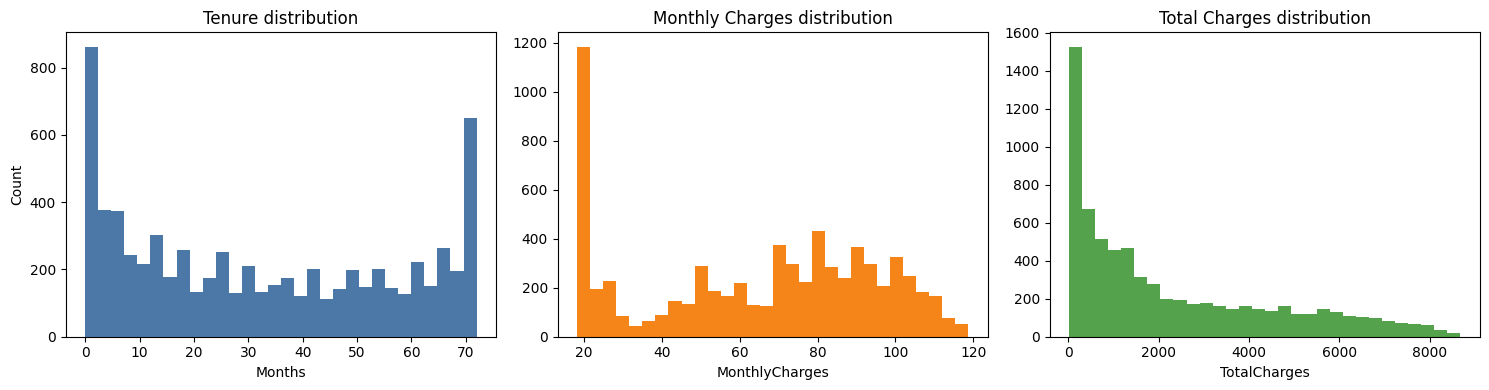

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["tenure"], bins=30, color="#4C78A8")
axes[0].set_title("Tenure distribution")
axes[0].set_xlabel("Months")
axes[0].set_ylabel("Count")

axes[1].hist(df["MonthlyCharges"], bins=30, color="#F58518")
axes[1].set_title("Monthly Charges distribution")
axes[1].set_xlabel("MonthlyCharges")

axes[2].hist(df["TotalCharges"], bins=30, color="#54A24B")
axes[2].set_title("Total Charges distribution")
axes[2].set_xlabel("TotalCharges")

plt.tight_layout()
plt.show()

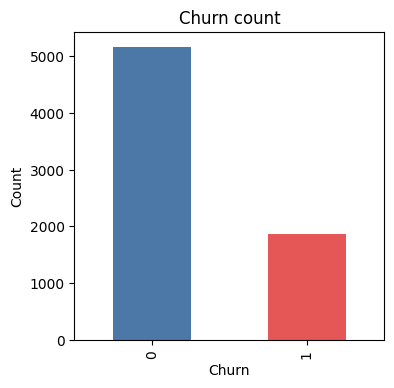

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C78A8", "#E45756"], ax=ax)
ax.set_title("Churn count"); ax.set_xlabel("Churn"); ax.set_ylabel("Count")
plt.show()

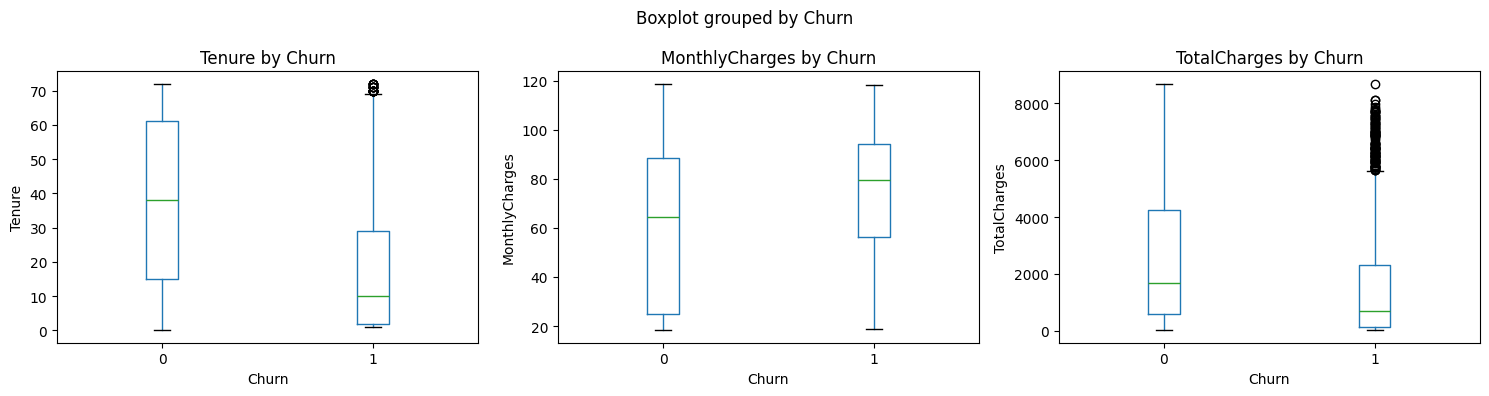

In [16]:
# Outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure vs Churn
df.boxplot(column="tenure", by="Churn", ax=axes[0], grid=False)
axes[0].set_title("Tenure by Churn"); axes[0].set_xlabel("Churn"); axes[0].set_ylabel("Tenure")
axes[0].figure.suptitle("")

# MonthlyCharges vs Churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[1], grid=False)
axes[1].set_title("MonthlyCharges by Churn"); axes[1].set_xlabel("Churn"); axes[1].set_ylabel("MonthlyCharges")

# TotalCharges vs Churn
df.boxplot(column="TotalCharges", by="Churn", ax=axes[2], grid=False)
axes[2].set_title("TotalCharges by Churn"); axes[2].set_xlabel("Churn"); axes[2].set_ylabel("TotalCharges")

plt.tight_layout()
plt.show()


In [17]:
z = (df['TotalCharges'] - df['TotalCharges'].mean())/df['TotalCharges'].std()
outliers = df[np.abs(z) > 2]
print(f"Number of outliers in TotalCharges: {outliers.shape[0]}")

df['TotalCharges'] = np.log1p(df['TotalCharges'])

Number of outliers in TotalCharges: 395


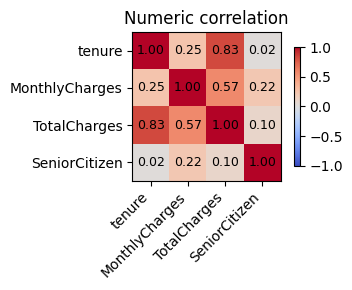

In [18]:
# Heat Map
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
ax.set_title("Numeric correlation")

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", va="center", ha="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## Data Processing

In [19]:
from sklearn.preprocessing import LabelEncoder

def object_to_int(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [20]:
df = df.apply(lambda x: object_to_int(x))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,ServiceCount,SupportTickets,HighComplaintFlag
0,0,0,1,0,1,0,1,0,0,2,...,1,2,29.85,3.429137,0,0-1yr,14.925000,1,2,0
1,1,0,0,0,34,1,0,0,2,0,...,0,3,56.95,7.544597,0,2-4yr,53.985714,3,1,0
2,1,0,0,0,2,1,0,0,2,2,...,1,3,53.85,4.692723,1,0-1yr,36.050000,3,0,0
3,1,0,0,0,45,0,1,0,2,0,...,0,0,42.30,7.518471,0,2-4yr,40.016304,3,0,0
4,0,0,0,0,2,1,0,1,0,0,...,1,2,70.70,5.028148,1,0-1yr,50.550000,1,3,0


# Feature Selection

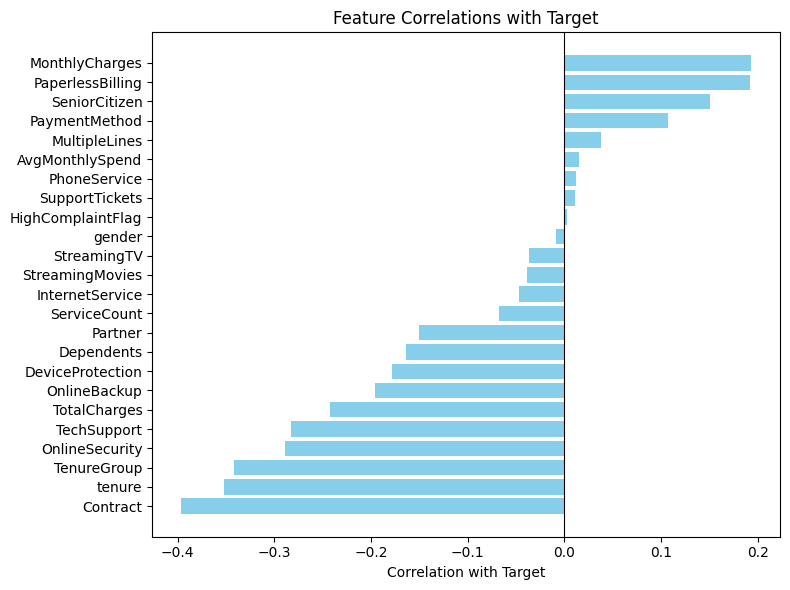

In [21]:
if isinstance(df['TenureGroup'].dtype, pd.CategoricalDtype):
    df['TenureGroup'] = df['TenureGroup'].cat.codes

corr = df.corr()["Churn"].sort_values(ascending=False)

# Assuming 'target' is your target column
corr = df.corr()['Churn'].drop('Churn')  # correlations with target, excluding itself

# Sort for nicer plotting
corr = corr.sort_values()

plt.figure(figsize=(8, 6))
plt.barh(corr.index, corr.values, color='skyblue')
plt.xlabel("Correlation with Target")
plt.title("Feature Correlations with Target")
plt.axvline(0, color='black', linewidth=0.8)  # reference line at 0
plt.tight_layout()
plt.show()

In [22]:
df = df.drop(columns=['gender','HighComplaintFlag','SupportTickets'], axis=1, errors='ignore')

In [23]:
y = df['Churn']
x = df.drop(columns =['Churn'])

In [24]:
# Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=7
)

## Model Selection and Training

### Evaluating all Models

In [25]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define models ONLY for comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=500,max_depth=10,min_samples_split=2,min_samples_leaf=1,max_features=0.8,bootstrap=True,
                                            random_state=7,n_jobs=-1,class_weight='balanced')
}

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Show comparison clearly
import pandas as pd
comparison_df = pd.DataFrame.from_dict(accuracy_results, orient='index', columns=['Accuracy']).sort_values(by='Accuracy', ascending=False)
comparison_df


Logistic Regression Accuracy: 0.8155
Decision Tree Accuracy: 0.7360
Random Forest Accuracy: 0.7928


,Accuracy
Logistic Regression,0.815472
Random Forest,0.792761
Decision Tree,0.735983


## Model Evaluation

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1035
           1       0.59      0.71      0.64       374

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409

ROC-AUC Score: 0.8523211656203983


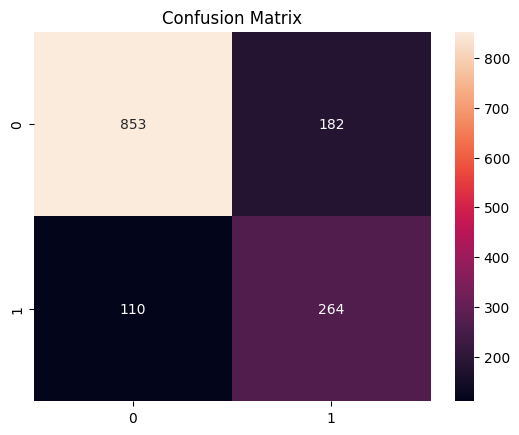

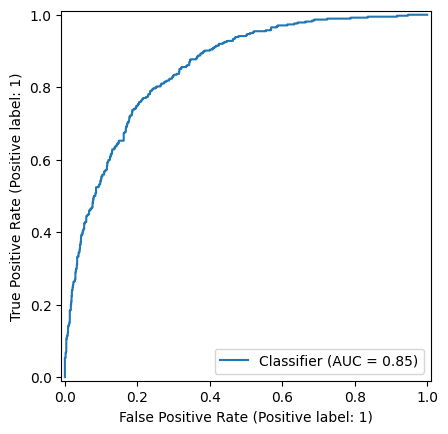

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
rf = RandomForestClassifier(n_estimators=500,max_depth=10,min_samples_split=2,min_samples_leaf=1,
                            max_features=0.8,
                            bootstrap=True,
                            random_state=7,n_jobs=-1,class_weight='balanced')
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, preds))
print("ROC-AUC Score:", roc_auc_score(y_test, probs))

sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, probs)
plt.show()

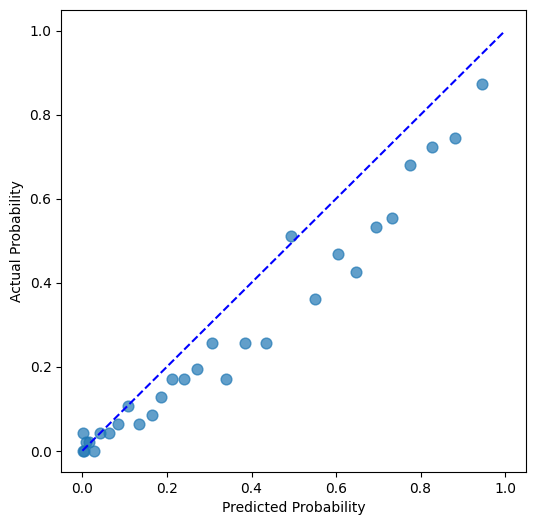

In [27]:
rf.fit(X_train, y_train)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

df = pd.DataFrame({"y_test": y_test, "y_pred_prob": y_pred_prob})

df['bin'] = pd.qcut(df['y_pred_prob'], q=30, duplicates='drop')

calibration = df.groupby('bin', observed= False).agg({
    'y_pred_prob': 'mean',
    'y_test': 'mean'
}).reset_index()

# Scatter plot (calibrated style)
plt.figure(figsize=(6,6))
plt.scatter(calibration['y_pred_prob'], calibration['y_test'], s=60, alpha=0.7)
plt.plot([0,1],[0,1],'b--')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.show()


Live Prediction

In [28]:
sample_customer = X_test.iloc[10].to_frame().T
prediction = rf.predict(sample_customer)
probability = rf.predict_proba(sample_customer)[0][1]

print("Prediction:", "Customer WILL Churn" if prediction[0]==1 else "Customer will NOT Churn")
print("Churn Probability:", round(probability*100,2), "%")

Prediction: Customer will NOT Churn
Churn Probability: 0.15 %


# Improved Random Forest Model
Enhancements added:
- Hyperparameter tuning using GridSearchCV
- Feature importance analysis
- Evaluation using Accuracy, Confusion Matrix, and ROC-AUC


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.7920511000709723

Confusion Matrix:
 [[850 185]
 [108 266]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.82      0.85      1035
           1       0.59      0.71      0.64       374

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409

ROC-AUC Score: 0.851298147717585


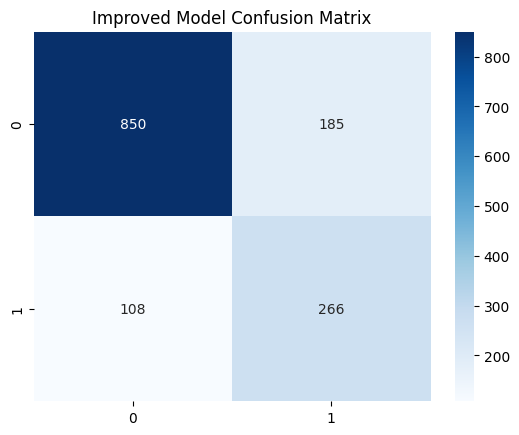


Top 10 Important Features:
Contract            0.299705
MonthlyCharges      0.123984
TotalCharges        0.112672
AvgMonthlySpend     0.099888
tenure              0.090974
OnlineSecurity      0.069131
TechSupport         0.038412
PaymentMethod       0.028783
InternetService     0.020828
PaperlessBilling    0.015448
dtype: float64


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Define model
rf = RandomForestClassifier(n_estimators=500,max_depth=10,min_samples_split=2,min_samples_leaf=1,max_features=0.8,bootstrap=True,
                                            random_state=7,n_jobs=-1,class_weight='balanced')

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring='recall')
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# Evaluation
print('Best Parameters:', grid_rf.best_params_)
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues')
plt.title("Improved Model Confusion Matrix")
plt.show()
# Feature Importance
import pandas as pd
feature_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns)
print('\nTop 10 Important Features:')
print(feature_importance.sort_values(ascending=False).head(10))


## Final Random Forest Evaluation

In [36]:

# Final Evaluation of Tuned Random Forest
y_pred_rf = best_rf.predict(X_test)

print("Final Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Final Random Forest Accuracy: 0.7920511000709723

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1035
           1       0.59      0.71      0.64       374

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409

